In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)



100%|██████████| 652k/652k [00:00<00:00, 1.11MB/s]

Extracting files...
Path to dataset files: /home/samuele/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2


In [3]:
path = "Datasets/adult.csv"
df = pd.read_csv(path)

In [4]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
df = df.drop(columns=["education"]) # eliminiamo perchè ridondante con "education_num"

df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### Distribuzione della classe Selector (il target)

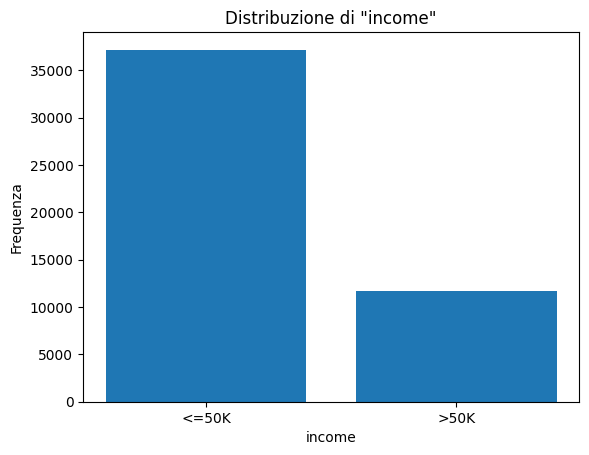

In [6]:
conteggi = df["income"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("income")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "income"')
plt.show()

### Creazione trainining e testing set

In [7]:
feature_names = set(df.columns) - set(["income"])

target_name = "income"

categorical_features = set(["workclass", "marital-status", "occupation", "relationship", "race", "native-country", "gender"])
continuos_features = feature_names - set(["workclass", "marital-status", "occupation", "relationship", "race", "native-country","gender"])

print("categoriche: " + ", ".join(categorical_features))
print("continue: " + ", ".join(continuos_features))
feature_names = list(feature_names)

categoriche: gender, occupation, native-country, workclass, relationship, race, marital-status
continue: hours-per-week, capital-loss, capital-gain, age, fnlwgt, educational-num


In [8]:
df_encoded = df.copy()

df_encoded["workclass"] = df_encoded["workclass"].astype("category").cat.codes
df_encoded["marital-status"] = df_encoded["marital-status"].astype("category").cat.codes
df_encoded["occupation"] = df_encoded["occupation"].astype("category").cat.codes
df_encoded["relationship"] = df_encoded["relationship"].astype("category").cat.codes
df_encoded["race"] = df_encoded["race"].astype("category").cat.codes
df_encoded["native-country"] = df_encoded["native-country"].astype("category").cat.codes
df_encoded["gender"] = df_encoded["gender"].astype("category").cat.codes

df_encoded["income"] = df_encoded["income"].astype("category").cat.codes

In [9]:
df_encoded

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,10,4,0,3,4,0,0,0,30,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,4,257302,12,2,13,5,4,0,0,0,38,39,0
48838,40,4,154374,9,2,7,0,4,1,0,0,40,39,1
48839,58,4,151910,9,6,1,4,4,0,0,0,40,39,0
48840,22,4,201490,9,4,1,3,4,1,0,0,20,39,0


In [10]:
df_encoded["income"].dtype

dtype('int8')

In [11]:
df_encoded["gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [12]:
y = df_encoded["income"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [13]:
df_encoded.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,10,4,0,3,4,0,0,0,30,39,0


In [14]:
X_train.head()

,gender,occupation,hours-per-week,capital-loss,native-country,capital-gain,workclass,age,fnlwgt,relationship,race,marital-status,educational-num
38865,1,14,60,0,39,0,4,21,317175,1,4,4,9
17212,0,0,10,0,39,0,0,19,52114,3,4,4,10
9312,1,0,45,0,39,0,0,32,340580,0,2,2,9
15512,1,14,40,0,39,0,4,35,272944,1,4,0,13
23576,1,1,35,0,39,0,4,21,174714,3,4,4,12


In [15]:
y_train.head()

38865    0
17212    0
9312     0
15512    0
23576    0
Name: income, dtype: int8

In [ ]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [ ]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[9743 1404]
 [1323 2183]]

Accuracy: 0.8138947655770149


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88     11066
           1       0.62      0.61      0.62      3587

    accuracy                           0.81     14653
   macro avg       0.75      0.74      0.75     14653
weighted avg       0.81      0.81      0.81     14653



### Miglioriamo l'albero

In [ ]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [ ]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[10627   520]
 [ 1617  1889]]

Accuracy: 0.85415955776974


In [ ]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91     12244
           1       0.54      0.78      0.64      2409

    accuracy                           0.85     14653
   macro avg       0.75      0.83      0.77     14653
weighted avg       0.89      0.85      0.86     14653



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [ ]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 7.31229343e-06 1.16136425e-05 ... 1.96731050e-02
 2.52631631e-02 6.01288619e-02]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(6, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

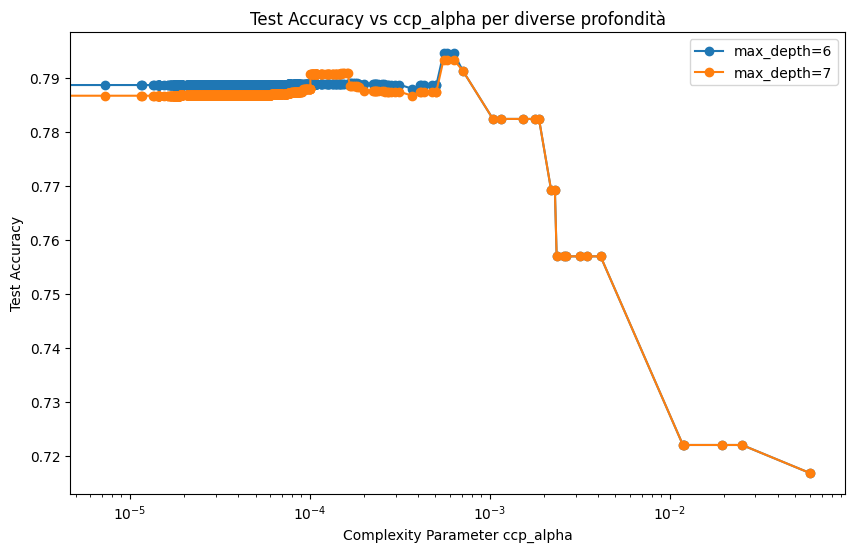

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(6, 8):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 6
Miglior ccp_alpha: 0.0005546649016216557
Train accuracy: 0.7959285150194507
Test accuracy: 0.7946495598171023


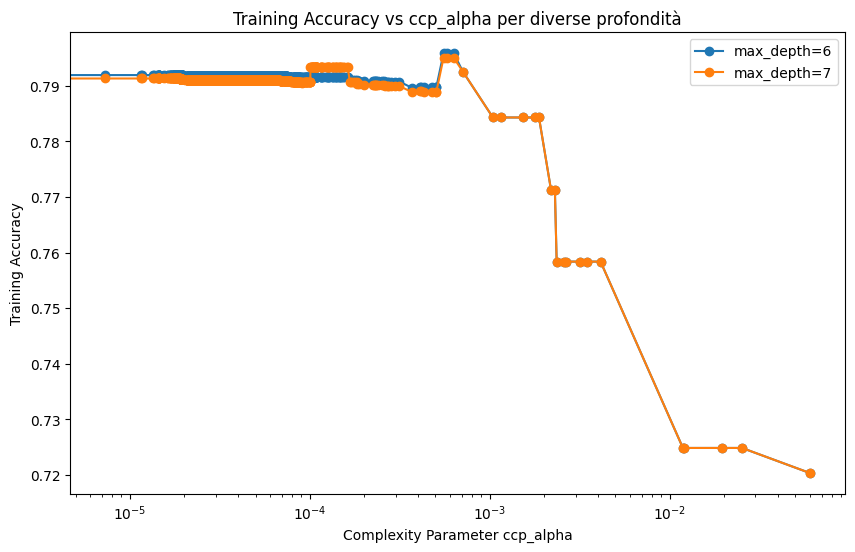

In [ ]:
plt.figure(figsize=(10, 6))

for depth in range(6, 8):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [ ]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7959285150194507
Accuracy test: 0.7946495598171023


In [ ]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[8654 2493]
 [ 516 2990]]

Accuracy: 0.7946495598171023


In [ ]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.78      0.94      0.85      9170
           1       0.85      0.55      0.67      5483

    accuracy                           0.79     14653
   macro avg       0.81      0.74      0.76     14653
weighted avg       0.80      0.79      0.78     14653



### diamo un occhiata con la balancedPrecision

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.78      0.85     11147
           1       0.55      0.85      0.67      3506

    accuracy                           0.79     14653
   macro avg       0.74      0.81      0.76     14653
weighted avg       0.85      0.79      0.81     14653

Balanced accuracy: 0.8145880562770272
[[8654 2493]
 [ 516 2990]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(6, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [ ]:
weights_to_try = [ #snellito
    {0: 1, 1: 1},
    {0: 1, 1: 2},
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas[::10],
    weights_to_try=weights_to_try,
    depths=range(7, 8), #snellito
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             7
ccp_alpha                      0.000047
class_weight               {0: 1, 1: 2}
weight_0                              1
weight_1                              2
train_accuracy                 0.824329
test_accuracy                  0.820446
train_balanced_accuracy        0.819602
test_balanced_accuracy         0.811307
precision_class_1              0.593264
recall_class_1                 0.793782
f1_class_1                     0.679029
macro_f1                       0.777195
weighted_f1                    0.828385
Name: 263, dtype: object

Confusion matrix:
[[9239 1908]
 [ 723 2783]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     11147
           1       0.59      0.79      0.68      3506

    accuracy                           0.82     14653
   macro avg       0.76      0.81      0.78     14653
weighted avg       0.85      0.82      0

In [ ]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88     11147
           1       0.59      0.79      0.68      3506

    accuracy                           0.82     14653
   macro avg       0.76      0.81      0.78     14653
weighted avg       0.85      0.82      0.83     14653



### Facciamo un ensemble a majority

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, part_index in splitter.split(X_train, y_train):
        X_part = X_train.iloc[part_index]
        y_part = y_train.iloc[part_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(6, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "accuracy": test_accuracy,
                    "balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [ ]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas[::10], # snellito
    weights_to_try=weights_to_try,
    depths=range(6, 8), #snellito come sopra
    scoring_metric="f1_class_1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.00020096050644057223), 'class_weight': {0: 1, 1: 2}, 'weight_0': 1, 'weight_1': 2, 'accuracy': 0.8128028390090767, 'balanced_accuracy': 0.8154729149547475, 'precision_class_1': 0.576437587657784, 'recall_class_1': 0.820593268682259, 'f1_class_1': 0.6771801812404378, 'macro_f1': 0.7726811089296042, 'weighted_f1': 0.8224813265282476}

Confusion matrix:
[[9033 2114]
 [ 629 2877]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     11147
           1       0.58      0.82      0.68      3506

    accuracy                           0.81     14653
   macro avg       0.76      0.82      0.77     14653
weighted avg       0.85      0.81      0.82     14653

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.6771801812404378


In [ ]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
1120,7,0.000201,"{0: 1, 1: 2}",1,2.0,0.812803,0.815473,0.576438,0.820593,0.677180,0.772681,0.822481
1102,7,0.000099,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1105,7,0.000104,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1096,7,0.000087,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1108,7,0.000108,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1099,7,0.000093,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1093,7,0.000085,"{0: 1, 1: 2}",1,2.0,0.812735,0.815037,0.576445,0.819452,0.676796,0.772487,0.822387
1114,7,0.000137,"{0: 1, 1: 2}",1,2.0,0.812666,0.815090,0.576298,0.819738,0.676793,0.772452,0.822335
1072,7,0.000068,"{0: 1, 1: 2}",1,2.0,0.812666,0.814992,0.576329,0.819452,0.676717,0.772420,0.822326
1066,7,0.000066,"{0: 1, 1: 2}",1,2.0,0.812666,0.814992,0.576329,0.819452,0.676717,0.772420,0.822326


In [ ]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87     11147
           1       0.58      0.82      0.68      3506

    accuracy                           0.81     14653
   macro avg       0.76      0.82      0.77     14653
weighted avg       0.85      0.81      0.82     14653



### proviamo  a fare undersampling del dataframe

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


def train_test_split_with_undersampling(
    df,
    target_col,
    test_size=0.3,
    random_state=42,
    stratify=False
):
    """
    Divide il DataFrame in train/test e applica undersampling solo al training set.

    Parametri:
    - df: DataFrame completo
    - target_col: nome della colonna target, esempio "Selector"
    - test_size: percentuale del test set
    - random_state: seed per riproducibilità
    - stratify: se True, mantiene proporzioni simili delle classi nello split

    Ritorna:
    - X_train_under
    - X_test
    - y_train_under
    - y_test
    """

    X = df.drop(columns=[target_col])
    y = df[target_col]

    if stratify:
        stratify_values = y
    else:
        stratify_values = None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_values
    )

    train_df = X_train.copy()
    train_df[target_col] = y_train

    class_counts = train_df[target_col].value_counts()
    min_class_count = class_counts.min()

    undersampled_parts = []

    for class_value in class_counts.index:
        class_df = train_df[train_df[target_col] == class_value]

        class_df_under = class_df.sample(
            n=min_class_count,
            random_state=random_state
        )

        undersampled_parts.append(class_df_under)

    train_df_under = pd.concat(undersampled_parts)

    train_df_under = train_df_under.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X_train_under = train_df_under.drop(columns=[target_col])
    y_train_under = train_df_under[target_col]

    return X_train_under, X_test, y_train_under, y_test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df=df_encoded,
    target_col="income",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [ ]:
y_train.value_counts()

income
1    8267
0    8267
Name: count, dtype: int64

In [ ]:
X_test.count()

age                14653
workclass          14653
fnlwgt             14653
educational-num    14653
marital-status     14653
occupation         14653
relationship       14653
race               14653
gender             14653
capital-gain       14653
capital-loss       14653
hours-per-week     14653
native-country     14653
dtype: int64

In [ ]:
weights_to_try = [ #snellito di più secondo i risultati precedenti
    {0: 1, 1: 1},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
]

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas[::10], # snellito
    weights_to_try=weights_to_try,
    depths=range(6, 8), #snellito
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.00027070779522112356), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.7931481607861871, 'balanced_accuracy': 0.8228848609698971, 'precision_class_1': 0.5346023839174524, 'recall_class_1': 0.8786549707602339, 'f1_class_1': 0.6647494746156398, 'macro_f1': 0.7575906267724141, 'weighted_f1': 0.8070936583564499}

Confusion matrix:
[[8617 2616]
 [ 415 3005]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     11233
           1       0.53      0.88      0.66      3420

    accuracy                           0.79     14653
   macro avg       0.74      0.82      0.76     14653
weighted avg       0.86      0.79      0.81     14653

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.6647494746156398


In [ ]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.77      0.85     11233
           1       0.53      0.88      0.66      3420

    accuracy                           0.79     14653
   macro avg       0.74      0.82      0.76     14653
weighted avg       0.86      0.79      0.81     14653



### Usiamo le random forests

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def search_best_random_forest(
    X_train,
    y_train,
    X_test,
    y_test,
    n_estimators_to_try,
    depths_to_try,
    weights_to_try,
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_model = None
    best_score = -1
    best_row = None
    best_predictions = None

    for n_estimators in n_estimators_to_try:
        for max_depth in depths_to_try:
            for weights in weights_to_try:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    class_weight=weights,
                    random_state=random_state,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                y_pred_train = rf.predict(X_train)
                y_pred_test = rf.predict(X_test)

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "class_weight": weights,
                    "weight_0": weights[0] if isinstance(weights, dict) else None,
                    "weight_1": weights[1] if isinstance(weights, dict) else None,

                    "train_accuracy": accuracy_score(y_train, y_pred_train),
                    "test_accuracy": accuracy_score(y_test, y_pred_test),
                    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),

                    "precision_class_1": precision_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "recall_class_1": recall_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "f1_class_1": f1_score(
                        y_test,
                        y_pred_test,
                        pos_label=1,
                        zero_division=0
                    ),
                    "macro_f1": f1_score(
                        y_test,
                        y_pred_test,
                        average="macro",
                        zero_division=0
                    )
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_model = rf
                    best_row = row
                    best_predictions = y_pred_test

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    return best_model, results_df, best_row, best_predictions

In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

In [ ]:
# best_rf.fit(X_train, y_train)

# y_pred_test = best_rf.predict(X_test)
# print(classification_report(y_test, y_pred_test, zero_division=0))

In [ ]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [ ]:
# funzione per sporcare variabili categoriche
import numpy as np

import numpy as np



def corrupt_rows_cat(X_train, col, frac=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    # Generatore casuale riproducibile
    rng = np.random.default_rng(random_state)

    # Recupero i valori univoci della colonna
    unique_values = X_train_corrupt[col].unique()

    # Se esiste un solo valore, non posso sostituirlo con qualcosa di diverso
    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return X_train_corrupt

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo righe casuali senza ripetizione
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Per ogni riga scelta, sostituisco il valore con un altro diverso
    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        X_train_corrupt.at[idx, col] = rng.choice(pool_of_new_values)

    return X_train_corrupt


def corrupt_rows_cont(X_train, col, frac=0.1, noise_level=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    # Converto la colonna in float, così posso inserirci valori decimali
    X_train_corrupt[col] = X_train_corrupt[col].astype(float)

    # Numero di righe da corrompere
    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    # Scelgo gli indici delle righe da corrompere
    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    # Deviazione standard della colonna
    std_col = X_train_corrupt[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return X_train_corrupt

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        X_train_corrupt.at[idx, col] = current_value + noise

    return X_train_corrupt



### mostro le variabili dalla più importante alla meno importante

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# separo feature e target
X = df_encoded.drop(columns=["income"])
y = df_encoded["income"]

# scrivi qui le colonne categoriche
categoriche = ["Gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

          variabile  importanza
6      relationship    0.117243
4    marital-status    0.112085
9      capital-gain    0.082721
3   educational-num    0.065783
0               age    0.065199
5        occupation    0.062429
11   hours-per-week    0.043065
2            fnlwgt    0.039123
10     capital-loss    0.035477
8            gender    0.032701
1         workclass    0.018523
12   native-country    0.014866
7              race    0.013628


In [ ]:
feature_ordinate = importanza_variabili["variabile"].tolist()
n = len(feature_ordinate)
meta = n // 2

if n % 2 == 0:
    migliori = feature_ordinate[:meta]
    peggiori = feature_ordinate[meta:]
else:
    # la feature centrale appartiene a entrambe le liste
    migliori = feature_ordinate[:meta + 1]
    peggiori = feature_ordinate[meta:]

print("Migliori:", migliori)
print("Peggiori:", peggiori)

Migliori: ['relationship', 'marital-status', 'capital-gain', 'educational-num', 'age', 'occupation', 'hours-per-week']
Peggiori: ['hours-per-week', 'fnlwgt', 'capital-loss', 'gender', 'workclass', 'native-country', 'race']


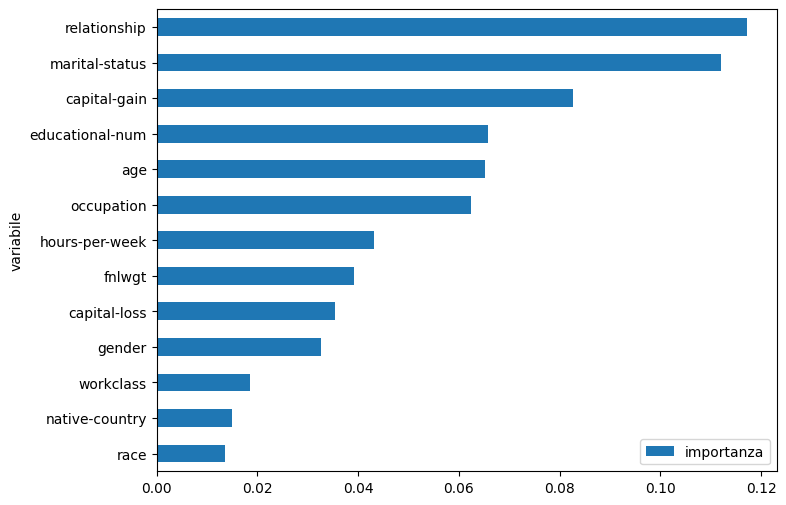

In [ ]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [ ]:
df_encoded.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,10,4,0,3,4,0,0,0,30,39,0


In [ ]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [ ]:
non_corrupted_data = [X_train, X_test, y_train, y_test]

In [ ]:
#occhio, sto sovrascrivendo gli x_train e y_train puliti,non è un errore ma bisogna ricordarselo
X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
    df_encoded,
    target_col="income",
    test_size=0.3,
    random_state=42,
    stratify=False
)

In [ ]:
# df_corrotto = corrupt_rows_cont(
#     df_encoded,
#     col="Sgpt",
#     frac=0.2,
#     noise_level=0.1,
#     random_state=42
# )

In [ ]:
noise_training_results = [] #best_models, results_df, best_row, best_predictions 

noise_training_results= search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas[::10], # snellito
    weights_to_try=weights_to_try,
    depths=range(6, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 7, 'ccp_alpha': np.float64(0.00027070779522112356), 'class_weight': 'balanced', 'weight_0': 'b', 'weight_1': 'a', 'accuracy': 0.7932164061966833, 'balanced_accuracy': 0.8229293726764759, 'precision_class_1': 0.5346975088967971, 'recall_class_1': 0.8786549707602339, 'f1_class_1': 0.6648230088495575, 'macro_f1': 0.7576557558804187, 'weighted_f1': 0.8071543058396161}

Confusion matrix:
[[8618 2615]
 [ 415 3005]]

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     11233
           1       0.53      0.88      0.66      3420

    accuracy                           0.79     14653
   macro avg       0.74      0.82      0.76     14653
weighted avg       0.86      0.79      0.81     14653

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.6648230088495575


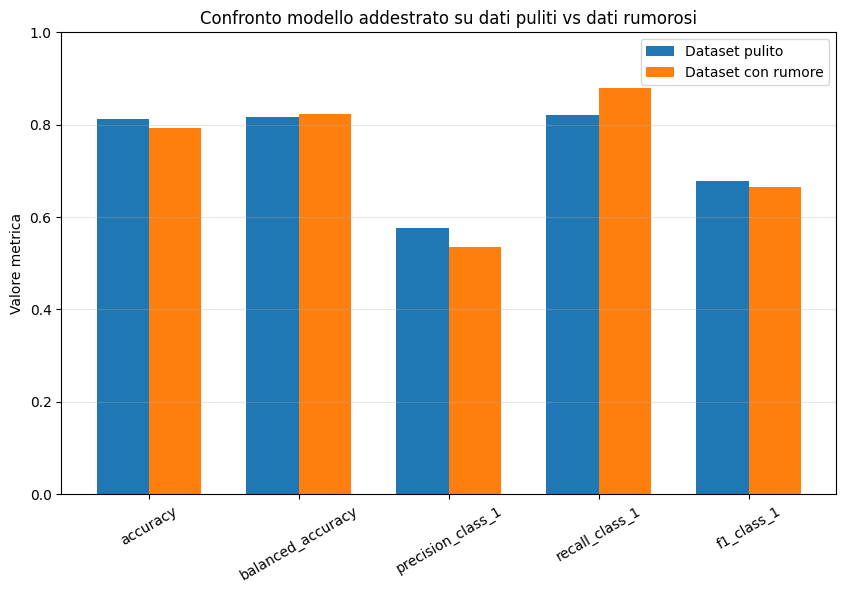

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
df_encoded.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,10,4,0,3,4,0,0,0,30,39,0


In [ ]:

# X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
#     df=df_encoded,
#     target_col="Gender",
#     test_size=0.7,
#     random_state=42,
#     stratify=False
# )



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier


def train_three_trees_noise(
    X_train, y_train, max_depth, ccp_alpha, class_weight, random_state=42
):
    """Versione corretta usata soltanto dagli esperimenti sul rumore."""
    models = []
    splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    for fold_number, (train_index, _) in enumerate(splitter.split(X_train, y_train)):
        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )
        tree.fit(X_train.iloc[train_index], y_train.iloc[train_index])
        models.append(tree)

    return models


def search_best_ensemble_tree_noise(*args, **kwargs):
    original_train_function = globals()["train_three_trees"]
    globals()["train_three_trees"] = train_three_trees_noise
    try:
        return search_best_ensemble_tree(*args, **kwargs)
    finally:
        globals()["train_three_trees"] = original_train_function


# La classe 1 è minoritaria in questo dataset.
tree_weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]


def test_noise_progressivo(
    df,
    target_col,
    cols_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    scoring_metric="f1_class_1",
    feature_group=None,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non devi sporcare la colonna target.")

    # Split train/validation/test. Il test non partecipa alla selezione.
    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    # La Mutual Information viene calcolata esclusivamente sul training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        discrete_mask = [col in categorical_cols for col in X_train_full.columns]
        mi = mutual_info_classif(
            X_train_full,
            y_train_full,
            discrete_features=discrete_mask,
            random_state=random_state
        )
        ordered_features = [
            col for _, col in sorted(
                zip(mi, X_train_full.columns), reverse=True
            )
        ]
        middle = len(ordered_features) // 2
        cols_to_corrupt = (
            ordered_features[:middle]
            if feature_group == "migliori"
            else ordered_features[middle:]
        )

    # ✔ identificazione tipo colonne
    tipo_colonne = {}

    for col in cols_to_corrupt:

        is_categorical = (
            col in categorical_cols or
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool" or
            (
                pd.api.types.is_integer_dtype(df[col]) and
                df[col].nunique() <= max_unique_for_cat
            )
        )

        tipo_colonne[col] = is_categorical

    print("Colonne da corrompere:")
    for col, is_cat in tipo_colonne.items():
        print(f" - {col}: {'categorica' if is_cat else 'continua'}")

    # ✔ rumore progressivo (include 0%)
    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        # reset train base
        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ applicazione rumore su più colonne
        for col_index, col in enumerate(cols_to_corrupt):

            # Seed diverso per colonna, stabile tra i livelli di rumore.
            column_seed = random_state + col_index

            if tipo_colonne[col]:

                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=column_seed
                )

            else:

                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=column_seed
                )

        # ✔ training modello (ensemble tree search invariato)
        training_results = search_best_ensemble_tree_noise(
            X_train=X_train,
            y_train=y_train,
            # La configurazione viene scelta sul validation set.
            X_test=X_val,
            y_test=y_val,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, validation_predictions = training_results

        # Il test set viene usato soltanto dopo la selezione dei parametri.
        best_predictions = predict_ensemble(best_models, X_test)
        accuracy = accuracy_score(y_test, best_predictions)
        balanced_accuracy = balanced_accuracy_score(y_test, best_predictions)
        precision = precision_score(y_test, best_predictions, pos_label=1, zero_division=0)
        recall = recall_score(y_test, best_predictions, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, best_predictions, pos_label=1, zero_division=0)

        # ✔ normalizzazione best_row
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row formato non valido")

        best_row_dict.update({
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "f1_class_1": f1,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "tipo_colonne": str(tipo_colonne),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_finali.append(best_row_dict)

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions,
            "accuracy": accuracy
        }

    # ✔ dataframe finale
    risultati_df = pd.DataFrame(risultati_finali)

    # ✔ metriche disponibili
    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    metriche_presenti = [
        m for m in metriche_possibili if m in risultati_df.columns
    ]

    print(risultati_df)

    # ✔ grafico
    plt.figure(figsize=(10, 6))

    for m in metriche_presenti:

        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale di rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza ensemble alberi su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

In [ ]:
df_encoded.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,7,4,7,3,2,1,0,0,40,39,0
1,38,4,89814,9,2,5,0,4,1,0,0,50,39,0
2,28,2,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,4,160323,10,2,7,0,2,1,7688,0,40,39,1
4,18,0,103497,10,4,0,3,4,0,0,0,30,39,0


In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=peggiori,
    ccp_alphas=ccp_alphas[::10], # snellito
    weights_to_try=tree_weights_to_try,
    depths=range(7, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    feature_group="peggiori",
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True
)


In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=migliori,
    ccp_alphas=ccp_alphas[::10],
    weights_to_try=tree_weights_to_try,
    depths=range(7, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    feature_group="migliori",
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True
)

Inizio rete neurale


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf


In [ ]:
y = df_encoded["income"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred = model.predict(X_test)

# conversione probabilità in classi
y_pred = (y_pred > 0.5).astype(int)



cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
Confusion matrix:
 [[10435   712]
 [ 2104  1402]]

Accuracy: 0.8078209240428581


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_NN(input_dim, seed=None):
    tf.keras.backend.clear_session()

    if seed is not None:
        tf.keras.utils.set_random_seed(seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


def ensemble_predict_NN(models, X):
    preds = []

    for m in models:
        preds.append(m.predict(X, verbose=0))

    mean_pred = np.mean(preds, axis=0)

    return (mean_pred > 0.5).astype(int).flatten()


def test_noise_progressivo_NN(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10,
    feature_group=None,
    n_repeats=5,
    ensemble_size=3
):
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.utils.class_weight import compute_class_weight

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    if target_col in cols_to_corrupt:
        raise ValueError("Non puoi sporcare il target")

    X = df.drop(columns=[target_col])

    # Il target è già codificato correttamente come 0/1.
    y = df[target_col].astype(int)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    # I gruppi di feature vengono determinati usando soltanto il training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        discrete_mask = [col in categorical_cols for col in X_train_full.columns]
        mi = mutual_info_classif(
            X_train_full,
            y_train_full,
            discrete_features=discrete_mask,
            random_state=random_state
        )
        ordered_features = [
            col for _, col in sorted(
                zip(mi, X_train_full.columns), reverse=True
            )
        ]
        middle = len(ordered_features) // 2
        cols_to_corrupt = (
            ordered_features[:middle]
            if feature_group == "migliori"
            else ordered_features[middle:]
        )

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {col: is_cat(col) for col in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, categorical in tipo_colonne.items():
        print(f" - {col}: {'categorica' if categorical else 'continua'}")

    classes = np.sort(y_train_full.unique())
    balanced_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_full
    )
    class_weights = dict(zip(classes, balanced_weights))
    print("Class weights:", class_weights)

    percentuali_rumore = [
        0, 0.1, 0.2, 0.3, 0.4, 0.5,
        0.6, 0.7, 0.8, 0.9, 1.0
    ]
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    for frac in percentuali_rumore:
        percentuale = int(frac * 100)
        print(f"\nRumore: {percentuale}%")
        repeat_metrics = []
        repeat_details = []

        for repeat in range(n_repeats):
            X_train = X_train_full.copy()
            y_train = y_train_full.copy()

            # Seed diverso per colonna e ripetizione, ma costante tra i livelli.
            for col_index, col in enumerate(cols_to_corrupt):
                column_seed = random_state + repeat * 1000 + col_index
                if tipo_colonne[col]:
                    X_train = corrupt_rows_cat(
                        X_train,
                        col=col,
                        frac=frac,
                        random_state=column_seed
                    )
                else:
                    X_train = corrupt_rows_cont(
                        X_train,
                        col=col,
                        frac=frac,
                        noise_level=noise_level,
                        random_state=column_seed
                    )

            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            models = []
            model_seeds = []

            for model_index in range(ensemble_size):
                # Lo stesso repeat/model usa bootstrap e inizializzazione uguali
                # per tutti i livelli: cambia soltanto il rumore nei dati.
                seed_i = random_state + repeat * 1000 + model_index
                model_seeds.append(seed_i)
                rng_bootstrap = np.random.default_rng(seed_i)
                idx = rng_bootstrap.choice(
                    len(X_train_scaled),
                    len(X_train_scaled),
                    replace=True
                )

                X_boot = X_train_scaled[idx]
                y_boot = y_train.iloc[idx].to_numpy()
                model = build_model_NN(
                    input_dim=X_train_scaled.shape[1],
                    seed=seed_i
                )
                model.fit(
                    X_boot,
                    y_boot,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val_scaled, y_val),
                    class_weight=class_weights,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=5,
                        restore_best_weights=True
                    )],
                    verbose=0,
                    shuffle=True
                )
                models.append(model)

            y_pred = ensemble_predict_NN(models, X_test_scaled)
            metrics = {
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "precision_class_1": precision_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "recall_class_1": recall_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "f1_class_1": f1_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                )
            }
            repeat_metrics.append(metrics)
            repeat_details.append({
                "repeat": repeat,
                "model_seeds": model_seeds,
                "y_pred": y_pred,
                "metrics": metrics
            })

            # Non conserviamo i modelli Keras di tutti i repeat in memoria.
            del models

        result = {
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": percentuale,
            "n_repeats": n_repeats
        }
        for metric in metric_names:
            values = np.array([row[metric] for row in repeat_metrics])
            result[metric] = values.mean()
            result[f"{metric}_std"] = values.std(ddof=1) if n_repeats > 1 else 0.0

        risultati_finali.append(result)
        risultati_completi[percentuale] = {
            "X_train_clean": X_train_full,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train_full,
            "y_val": y_val,
            "y_test": y_test,
            "class_weights": class_weights,
            "repeats": repeat_details
        }

    risultati_df = pd.DataFrame(risultati_finali)

    plt.figure(figsize=(10, 6))
    for metric in metric_names:
        plt.errorbar(
            risultati_df["percentuale_rumore"],
            risultati_df[metric],
            yerr=risultati_df[f"{metric}_std"],
            marker="o",
            capsize=3,
            label=metric
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche (media ± deviazione standard)")
    plt.title(f"Robustezza NN ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)
    return risultati_df, risultati_completi


In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    n_repeats=5,
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True,
)

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    n_repeats=5,
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True,
)

Inizio svg

In [ ]:
y = df_encoded["income"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Creazione del modello SVM
model = SVC(
    kernel="rbf",        
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

# Addestramento
model.fit(X_train, y_train)

# Predizioni
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

Confusion matrix:
 [[10673   474]
 [ 2458  1048]]

Accuracy: 0.7999044564253054


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_SVM():
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )
    return model


def ensemble_predict_SVM(models, X):

    preds = []

    for m in models:
        preds.append(m.predict(X))

    preds = np.array(preds)

    # Majority voting
    y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

    return y_pred




def test_noise_progressivo_SVM(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
    feature_group=None,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    # SPLIT UNA SOLA VOLTA (FIX come NN)
    X = df.drop(columns=[target_col])
    # Il target è già codificato correttamente come 0/1.
    y = df[target_col].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    # La selezione delle feature usa soltanto il training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        discrete_mask = [col in categorical_cols for col in X_train_full.columns]
        mi = mutual_info_classif(
            X_train_full,
            y_train_full,
            discrete_features=discrete_mask,
            random_state=random_state
        )
        ordered_features = [
            col for _, col in sorted(
                zip(mi, X_train_full.columns), reverse=True
            )
        ]
        middle = len(ordered_features) // 2
        cols_to_corrupt = (
            ordered_features[:middle]
            if feature_group == "migliori"
            else ordered_features[middle:]
        )
        tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, categorical in tipo_colonne.items():
        print(f" - {col}: {'categorica' if categorical else 'continua'}")

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # CORRUZIONE
        for col_index, col in enumerate(cols_to_corrupt):

            # Seed diverso per colonna, stabile tra i livelli di rumore.
            column_seed = random_state + col_index

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=column_seed
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=column_seed
                )

        # Scaling stimato esclusivamente sul training del livello corrente.
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        models = []

        # ENSEMBLE CON BOOTSTRAP (FIX come NN)
        for i in range(3):


            # quesra riga non va bene, non ha un seed
            #idx = np.random.choice(len(X_train), len(X_train), replace=True)
            #fix:
            seed_i = random_state + i
            rng = np.random.default_rng(seed_i)

            idx = rng.choice(
                len(X_train_scaled),
                len(X_train_scaled),
                replace=True
            )

            X_boot = X_train_scaled[idx]
            y_boot = y_train.iloc[idx].to_numpy()

            model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced"
            )

            model.fit(X_boot, y_boot)

            models.append(model)

        # PREDIZIONE ENSEMBLE (majority vote coerente)
        preds = []

        for m in models:
            preds.append(m.predict(X_test_scaled))

        preds = np.array(preds)

        y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

        # METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "scaler": scaler,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    # GRAFICO IDENTICO NN
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza SVM ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True,
)

In [ ]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="income",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    categorical_cols=['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country'],
    stratify=True,
)